# Task 1: Data Preparation
### SaiKet Systems — Data Science Internship
**Intern:** Omokhoa Oshose Tosayoname | **ID:** SKS/A2/C115874  
**Project:** Customer Churn Analysis and Prediction  
**Date:** April 2026

---

## Objective
Load the Telco Customer Churn dataset, perform initial exploration, handle missing values, encode categorical variables, and split the data into training and testing sets in preparation for downstream modelling tasks.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('telco_churn.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()


Dataset Shape: 7043 rows × 21 columns

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Initial Data Exploration
We examine the dataset's structure, data types, and basic statistics to understand what we are working with.


In [3]:
# Data types and non-null counts
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [4]:
# Statistical summary of numerical features
print("=== Descriptive Statistics (Numerical Columns) ===")
df.describe()


=== Descriptive Statistics (Numerical Columns) ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [5]:
# Column listing with dtypes
print("=== Column Names and Data Types ===")
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<12} | Unique values: {df[col].nunique()}")


=== Column Names and Data Types ===
  customerID                str          | Unique values: 7043
  gender                    str          | Unique values: 2
  SeniorCitizen             int64        | Unique values: 2
  Partner                   str          | Unique values: 2
  Dependents                str          | Unique values: 2
  tenure                    int64        | Unique values: 73
  PhoneService              str          | Unique values: 2
  MultipleLines             str          | Unique values: 3
  InternetService           str          | Unique values: 3
  OnlineSecurity            str          | Unique values: 3
  OnlineBackup              str          | Unique values: 3
  DeviceProtection          str          | Unique values: 3
  TechSupport               str          | Unique values: 3
  StreamingTV               str          | Unique values: 3
  StreamingMovies           str          | Unique values: 3
  Contract                  str          | Unique values: 3


## 4. Handling Missing Values
We check for null values and any hidden missing data (e.g. blank strings or whitespace entries).


In [6]:
# Standard null check
print("=== Null Value Count Per Column ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No null values detected.")
print(f"\nTotal null cells: {df.isnull().sum().sum()}")


=== Null Value Count Per Column ===
No null values detected.



Total null cells: 0


In [7]:
# TotalCharges is often imported as object due to blank strings — fix this
print("TotalCharges dtype before fix:", df['TotalCharges'].dtype)

# Convert TotalCharges to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)
print(f"NaN values introduced in TotalCharges: {df['TotalCharges'].isnull().sum()}")


TotalCharges dtype before fix: str
TotalCharges dtype after fix: float64
NaN values introduced in TotalCharges: 11


In [8]:
# Inspect rows with TotalCharges = NaN
missing_rows = df[df['TotalCharges'].isnull()]
print(f"Rows with missing TotalCharges: {len(missing_rows)}")
missing_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]


Rows with missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [9]:
# These customers have tenure = 0 (brand new customers, no charges accrued yet)
# Impute TotalCharges with MonthlyCharges for these rows (logical imputation)
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

print("Missing values after imputation:", df['TotalCharges'].isnull().sum())
print("\nFinal null check across all columns:")
print(df.isnull().sum().sum(), "total null values remaining.")


Missing values after imputation: 0

Final null check across all columns:


0 total null values remaining.


## 5. Drop Non-Predictive Columns
The `customerID` column is a unique identifier with no predictive value and should be removed before modelling.


In [10]:
# Drop customerID — not a feature
df.drop(columns=['customerID'], inplace=True)
print(f"customerID dropped. New shape: {df.shape}")


customerID dropped. New shape: (7043, 20)


## 6. Categorical Variable Encoding
Machine learning algorithms require numerical input. We encode categorical columns using two strategies:
- **Binary columns** (Yes/No, Male/Female): Label Encoding (0/1)
- **Multi-class columns**: One-Hot Encoding to avoid imposing ordinal relationships


In [11]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")


Categorical columns (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
# Encode binary categorical columns with LabelEncoder
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
print(f"Binary columns to label-encode: {binary_cols}\n")

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"  {col}: encoded → {dict(enumerate(le.classes_))}")


Binary columns to label-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

  gender: encoded → {0: 'Female', 1: 'Male'}
  Partner: encoded → {0: 'No', 1: 'Yes'}
  Dependents: encoded → {0: 'No', 1: 'Yes'}
  PhoneService: encoded → {0: 'No', 1: 'Yes'}
  PaperlessBilling: encoded → {0: 'No', 1: 'Yes'}
  Churn: encoded → {0: 'No', 1: 'Yes'}


In [13]:
# One-Hot Encode multi-class categorical columns
multi_class_cols = [col for col in cat_cols if df[col].nunique() > 2]
print(f"Multi-class columns to one-hot encode: {multi_class_cols}\n")

df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)
print(f"Shape after one-hot encoding: {df.shape}")
df.head(3)


Multi-class columns to one-hot encode: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']



Shape after one-hot encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


In [14]:
# Verify all columns are now numeric
non_numeric = df.select_dtypes(include='object').columns.tolist()
if non_numeric:
    print(f"WARNING — Non-numeric columns remaining: {non_numeric}")
else:
    print("All columns are numeric. Encoding complete.")
print(f"\nFinal column list ({len(df.columns)} features):")
print(df.columns.tolist())


All columns are numeric. Encoding complete.

Final column list (31 features):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 7. Feature and Target Separation
We separate the dataset into:
- **X** — feature matrix (all predictors)
- **y** — target vector (`Churn`: 1 = churned, 0 = retained)


In [15]:
# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nChurn distribution:")
print(y.value_counts())
print(f"\nChurn rate: {y.mean()*100:.2f}%")


Feature matrix X shape: (7043, 30)
Target vector y shape: (7043,)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.54%


## 8. Target Variable Distribution

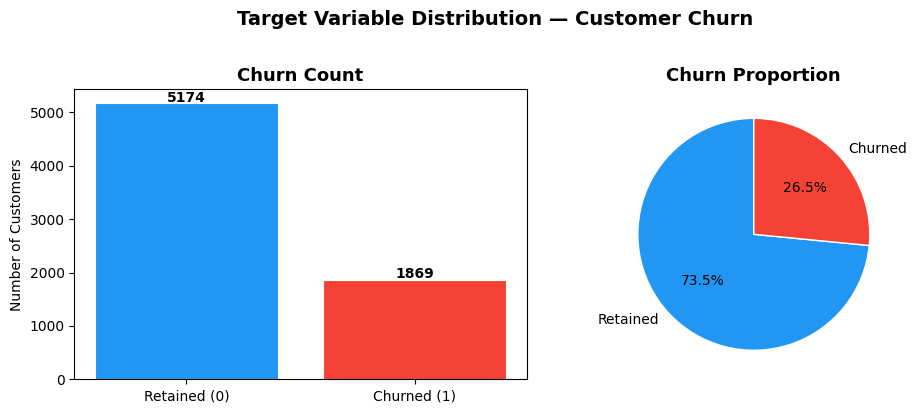

Plot saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
churn_counts = y.value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution — Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


## 9. Train-Test Split
We split the data using an **80/20 ratio** with stratification to preserve the churn class distribution in both sets. A fixed `random_state` ensures reproducibility.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves churn ratio in both splits
)

print("=== Train-Test Split Summary ===")
print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set    : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nChurn rate — Training set : {y_train.mean()*100:.2f}%")
print(f"Churn rate — Testing set  : {y_test.mean()*100:.2f}%")
print("\nStratification maintained: churn rates are consistent across both sets.")


=== Train-Test Split Summary ===
Training set   : 5634 samples (80.0%)
Testing set    : 1409 samples (20.0%)

Churn rate — Training set : 26.54%
Churn rate — Testing set  : 26.54%

Stratification maintained: churn rates are consistent across both sets.


## 10. Save Processed Data

In [18]:
# Save the cleaned, encoded dataset and splits for use in subsequent tasks
df.to_csv('telco_churn_processed.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Files saved:")
print("  telco_churn_processed.csv  — full cleaned & encoded dataset")
print("  X_train.csv                — training features")
print("  X_test.csv                 — testing features")
print("  y_train.csv                — training labels")
print("  y_test.csv                 — testing labels")


Files saved:
  telco_churn_processed.csv  — full cleaned & encoded dataset
  X_train.csv                — training features
  X_test.csv                 — testing features
  y_train.csv                — training labels
  y_test.csv                 — testing labels


## Summary

| Step | Action | Outcome |
|------|--------|---------|
| Data Loading | Read CSV | 7,043 rows × 21 columns |
| Exploration | Checked dtypes, stats, uniques | `TotalCharges` found as object dtype |
| Missing Values | Coerced `TotalCharges`, imputed 11 NaN rows | Zero remaining nulls |
| Column Removal | Dropped `customerID` | Non-predictive identifier removed |
| Encoding | Label + One-Hot encoding | All features converted to numeric |
| Split | 80/20 stratified train-test split | 5,634 train / 1,409 test |

The processed dataset and split files are ready for Task 2 (EDA) and Task 4 (Modelling).
